# Part 1: Loading the Foundation Model

In this section, we initialize the **DINOv2** backbone. DINOv2 is a state-of-the-art Self-Supervised Vision Transformer (ViT) from Meta AI. It is trained using a "discriminative self-supervised" approach, which allows it to learn high-quality spatial features without requiring labels.

### Key Configuration:
- **Model**: `dinov2_vitb14` (Vision Transformer - Base, 14px patch size).
- **Freezing**: We set `requires_grad = False` for all parameters as we are performing analysis (probing) rather than training.
- **Eval Mode**: `model.eval()` ensures that layers like Dropout or BatchNorm behave deterministically.


In [2]:
import torch

def load_dinov2_backbone():
    print("--- 🩺 Loading the DINOv2 ViT-B/14 ---")
    
    # Using 'dinov2_vitb14' as 'dinov2_vitb16' is not available in the current hub version.
    # We add trust_repo=True because Meta's repo is safe.
    model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14', trust_repo=True)
    
    for param in model.parameters():
        param.requires_grad = False
        
    model.eval()
    return model

def print_architecture_overview(model):
    # DINOv2 is made of 'blocks'. Each block is one layer.
    num_layers = len(model.blocks)
    
    # Inside each block is an 'attn' (attention) module
    # We can check how many heads are in the first layer
    num_heads = model.blocks[0].attn.num_heads
    
    print(f"\nModel Stats:")
    print(f"  - Total Layers: {num_layers}")
    print(f"  - Heads per Layer: {num_heads}")
    print(f"  - Total Attention Heads: {num_layers * num_heads}")
    
    # Let's peek at the first block's structure
    print("\nStructure of a Single Block (Layer):")
    print(model.blocks[0])


In [3]:
# 1. Load the model
dinov2 = load_dinov2_backbone()

# 2. Check the stats
print_architecture_overview(dinov2)

--- 🩺 Loading the DINOv2 ViT-B/14 ---


Using cache found in C:\Users\Madsl/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\Madsl/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\Madsl/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\Madsl/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")



Model Stats:
  - Total Layers: 12
  - Heads per Layer: 12
  - Total Attention Heads: 144

Structure of a Single Block (Layer):
NestedTensorBlock(
  (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (attn): MemEffAttention(
    (qkv): Linear(in_features=768, out_features=2304, bias=True)
    (proj): Linear(in_features=768, out_features=768, bias=True)
    (proj_drop): Dropout(p=0.0, inplace=False)
  )
  (ls1): LayerScale()
  (drop_path1): Identity()
  (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (mlp): Mlp(
    (fc1): Linear(in_features=768, out_features=3072, bias=True)
    (act): GELU(approximate='none')
    (fc2): Linear(in_features=3072, out_features=768, bias=True)
    (drop): Dropout(p=0.0, inplace=False)
  )
  (ls2): LayerScale()
  (drop_path2): Identity()
)


--- 

# Task 1: Quantifying Attention Behavior

In Vision Transformers, "Attention" is the mechanism that allows the model to weigh the importance of different spatial regions. Multi-Head Attention (MHA) allows the model to attend to different aspects of the image simultaneously.

We want to quantify how "focused" or "spread out" these attention heads are using two key metrics: **Entropy** and **Average Spatial Distance**.

### 1. Attention Entropy
Entropy measures the "uncertainty" or "diffusion" of the attention distribution for a given head.
- **Low Entropy**: The head is highly focused on a few specific patches (e.g., attending only to the eyes of a cat).
- **High Entropy**: The head's attention is spread broadly across many patches (e.g., looking at the entire background).

The formula used: $H = -\sum p_i \log(p_i)$

### 2. Average Spatial Distance
This metric captures the "physical" reach of a head. It calculates the weighted average distance between the patches that a head is attending to.
- **Local Heads**: Small distance. The head only looks at patches physically close to the query patch (similar to a convolution kernel).
- **Global Heads**: Large distance. The head looks at patches far away from the query patch, capturing long-range dependencies and global context.

### Capturing "Hidden" Attentions
Official DINOv2 implementations often use memory-efficient attention kernels (like FlashAttention) that do not explicitly materialize the $[N, N]$ attention matrix to save memory. 
To extract these maps for analysis, we:
1. Register a **Forward Hook** on the self-attention module.
2. Manually reconstruct the attention matrix: $\text{Softmax}(\frac{Q \cdot K^T}{\sqrt{d}})$.
3. Use a sample image from COCO (two cats) to trigger the forward pass.


# Part 2: Visualizing Specialized Heads

The following visualizations show the **CLS-to-Patch** attention. The `[CLS]` (Classification) token is a special token that aggregates information from all other patches to form the final image representation. By looking at which patches the `[CLS]` token attends to, we can see what the model thinks is most important for the final prediction.

### Entropy Visualization (Focus)
We compare the **Most Focused** (lowest entropy) head against the **Least Focused** (highest entropy) head. 
- You will notice the Focused head often highlights "sharp" semantic features like edges or specific object parts.
- The Diffused head often creates a "heat map" that covers large contextual areas or even the entire frame.

### Distance Visualization (Locality)
We compare the **Most Local** head (attends to nearby neighbors) against the **Most Global** head (attends across the whole image).
- Local heads are often found in the earlier layers of ViTs, acting like specialized filters.
- Global heads are critical for understanding the "big picture" and the relationship between distant objects.


---

# Task 2: Advanced Metrics - Importance and Magnitude

To further understand the role of each head, we introduce two more metrics:

### 3. Head Importance (Gradient-based Attribution)
We measure how much each head contributes to the final output by calculating the gradient of a "target" (e.g., the total sum of features or a specific class logit) with respect to the attention weights. 
- **Method**: Taylor expansion (first-order). Importance for a head $h$ is defined as $| \sum (\text{Attn}_h \times \frac{\partial \text{Loss}}{\partial \text{Attn}_h}) |$.
- **High Importance**: Small changes in this head's attention would significantly impact the model's decision.

### 4. Activation Magnitude ($L_2$ Norm)
This measures the "energy" or "strength" of the signals being passed through each head.
- **Method**: We calculate the $L_2$ norm of the output of the attention mechanism for each head (before the final projection).
- **High Magnitude**: The head is producing a strong signal, potentially carrying more information.


In [9]:
import torch
import pandas as pd
import numpy as np
from PIL import Image
import requests
from torchvision import transforms


def calculate_importance_and_magnitude(model, img_tensor):
    """
    Calculates gradient-based importance and activation magnitude for all heads.
    Since we don't have a specific downstream task (yet), we use the 
    mean of the CLS token feature as a surrogate target.
    """
    all_importances = [] # [Layers, Heads]
    all_magnitudes = []  # [Layers, Heads]
    
    # Store gradients and activations
    grads = {}
    activations = {}

    def get_attn_hook(layer_idx):
        def hook_fn(module, input, output):
            # Capture activation magnitude: ||head_output||_2
            # The output of DINOv2 blocks is actually the residual sum.
            # We want the output of the attention module specifically.
            # To be more precise, we can use the attention map weighted by values.
            
            x = input[0]
            B, N, C = x.shape
            num_heads = module.num_heads
            head_dim = C // num_heads
            
            # Manual attn to get intermediate head outputs
            qkv = module.qkv(x).reshape(B, N, 3, num_heads, head_dim).permute(2, 0, 3, 1, 4)
            q, k, v = qkv[0], qkv[1], qkv[2]
            attn = (q @ k.transpose(-2, -1)) * (head_dim)**-0.5
            attn = attn.softmax(dim=-1)
            
            # This allows us to track gradients with respect to the attention weights
            attn.retain_grad()
            grads[layer_idx] = attn 
            
            # Head output [Batch, Heads, Tokens, head_dim]
            head_out = attn @ v
            # Magnitude per head: [Batch, Heads]
            mag = torch.norm(head_out, p=2, dim=(-1, -2)) # Norm over tokens and dim
            activations[layer_idx] = mag.detach().cpu()
            
            # Reconstruct the original output to continue the forward pass
            # head_out: [B, H, N, D] -> [B, N, C]
            out = head_out.transpose(1, 2).reshape(B, N, C)
            return module.proj(out)
        return hook_fn

    # 1. Register hooks for all layers
    hooks = []
    for i, block in enumerate(model.blocks):
        hooks.append(block.attn.register_forward_hook(get_attn_hook(i)))

    # 2. Forward pass (enable gradients)
    # Ensure img_tensor requires grad for the attribution
    img_tensor.requires_grad_(True)
    out_features = model(img_tensor) # [1, 768] for ViT-B CLS token
    
    # Target: use mean of features (surrogate for "importance to the representation")
    target = out_features.mean()
    
    # 3. Backward pass
    model.zero_grad()
    target.backward()

    # 4. Extract metrics
    for i in range(len(model.blocks)):
        # Importance: |Attn * Grad| summed
        attn_weights = grads[i]
        importance = (attn_weights * attn_weights.grad).abs().sum(dim=(-1, -2))
        all_importances.append(importance.detach().cpu())
        all_magnitudes.append(activations[i])

    # Cleanup
    for h in hooks: h.remove()
    
    return torch.cat(all_importances, dim=0), torch.cat(all_magnitudes, dim=0)


def calculate_spatial_metrics(attn_map):
    """
    attn_map shape: [Heads, Num_Patches, Num_Patches]
    Note: We usually ignore the CLS token (index 0) for spatial distance.
    """
    num_heads = attn_map.shape[0]
    num_patches_total = attn_map.shape[1] - 1 # Excluding CLS
    grid_size = int(np.sqrt(num_patches_total)) # For B/14 on 224px, this is 16
    
    # 1. Calculate Entropy: -sum(p * log(p))
    entropy = -(attn_map * torch.log(attn_map + 1e-8)).sum(dim=-1).mean(dim=-1)
    
    # 2. Calculate Distance
    dist_matrix = torch.zeros((num_patches_total, num_patches_total))
    for i in range(num_patches_total):
        for j in range(num_patches_total):
            pos_i = np.array([i // grid_size, i % grid_size])
            pos_j = np.array([j // grid_size, j % grid_size])
            dist_matrix[i, j] = np.linalg.norm(pos_i - pos_j)
    
    attn_no_cls = attn_map[:, 1:, 1:] 
    attn_no_cls = attn_no_cls / (attn_no_cls.sum(dim=-1, keepdim=True) + 1e-8)
    
    distances = (attn_no_cls * dist_matrix.to(attn_map.device)).sum(dim=(-1, -2)) / num_patches_total

    return entropy, distances


def compute_all_head_metrics(model, img_tensor):
    """
    Computes all four metrics (Entropy, Distance, Importance, Magnitude) 
    for every head in every layer and returns a unified DataFrame.
    """
    census_data = []
    
    # 1. Storage for Hooks
    # We use dictionaries to store tensors from different layers
    captured_attns = {}
    captured_grads = {}
    captured_mags = {}

    def get_comprehensive_hook(layer_idx):
        def hook_fn(module, input, output):
            # input[0] is the hidden state [Batch, Tokens, Dim]
            x = input[0]
            B, N, C = x.shape
            num_heads = module.num_heads
            head_dim = C // num_heads
            
            # Manual Attention calculation to get the map AND track gradients
            # (Standard DINOv2 uses optimized kernels that hide these)
            qkv = module.qkv(x).reshape(B, N, 3, num_heads, head_dim).permute(2, 0, 3, 1, 4)
            q, k, v = qkv[0], qkv[1], qkv[2]
            
            # [Batch, Heads, Tokens, Tokens]
            attn = (q @ k.transpose(-2, -1)) * (head_dim)**-0.5
            attn = attn.softmax(dim=-1)
            
            # Track gradients for importance
            attn.retain_grad()
            captured_attns[layer_idx] = attn # Store original device tensor for grad check
            
            # Activation Magnitude: ||head_output||_2
            head_out = attn @ v
            # [Batch, Heads]
            mag = torch.norm(head_out, p=2, dim=(-1, -2))
            captured_mags[layer_idx] = mag.detach().cpu()
            
            # Return standard projection
            out = head_out.transpose(1, 2).reshape(B, N, C)
            return module.proj(out)
        return hook_fn

    # 2. Setup Device and Hooks
    device = next(model.parameters()).device
    hooks = []
    for i, block in enumerate(model.blocks):
        hooks.append(block.attn.register_forward_hook(get_comprehensive_hook(i)))

    # 3. Model Execution (Forward + Backward)
    img_tensor = img_tensor.to(device).requires_grad_(True)
    
    # DINOv2 output is often a dict; we target the CLS token feature
    outputs = model(img_tensor)
    if isinstance(outputs, dict):
        target_feature = outputs["x_norm_clstoken"]
    else:
        target_feature = outputs
        
    target = target_feature.mean()
    model.zero_grad()
    target.backward()

    # 4. Metric Processing
    for L in range(len(model.blocks)):
        # Extract Batch index 0
        attn_weights = captured_attns[L][0] 
        grads = captured_attns[L].grad[0]
        mags = captured_mags[L][0]
        
        # Calculate Spatial Metrics (Entropy & Distance)
        # Note: calculate_spatial_metrics was defined in previous cells
        entropy, distance = calculate_spatial_metrics(attn_weights)
        
        # Calculate Importance (Taylor attribution: |Attn * dL/dAttn|)
        importance = (attn_weights * grads).abs().sum(dim=(-1, -2))
        
        for H in range(attn_weights.shape[0]):
            census_data.append({
                "Layer": L,
                "Head": H,
                "Entropy": entropy[H].item(),
                "Distance": distance[H].item(),
                "Importance": importance[H].item(),
                "Magnitude": mags[H].item()
            })

    # Cleanup
    for h in hooks: h.remove()
    
    return pd.DataFrame(census_data)


url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw)
transform = transforms.Compose([
    transforms.Resize(224), transforms.CenterCrop(224), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
img_tensor = transform(image).unsqueeze(0).to(next(dinov2.parameters()).device)


# Run the complete census
df_census = compute_all_head_metrics(dinov2, img_tensor)

# Display results
print("\n--- Attention Census Complete ---")
print(f"Total Heads Analyzed: {len(df_census)}")
display(df_census.sort_values(by="Importance", ascending=False).head(10))



--- Attention Census Complete ---
Total Heads Analyzed: 144


,Layer,Head,Entropy,Distance,Importance,Magnitude
3,0,3,5.296564,8.262773,0.080239,65.445114
72,6,0,4.685068,5.853051,0.041097,40.345684
130,10,10,2.439574,9.357276,0.037706,48.326839
116,9,8,4.440669,6.348979,0.037109,47.133194
96,8,0,3.580601,2.942049,0.036609,60.419434
92,7,8,5.057546,7.127987,0.036385,25.203907
71,5,11,4.950935,6.107889,0.036207,27.585844
101,8,5,4.931684,7.316523,0.035674,34.965279
80,6,8,4.781044,7.330546,0.033892,23.985760
79,6,7,5.169952,8.237788,0.033045,23.970049


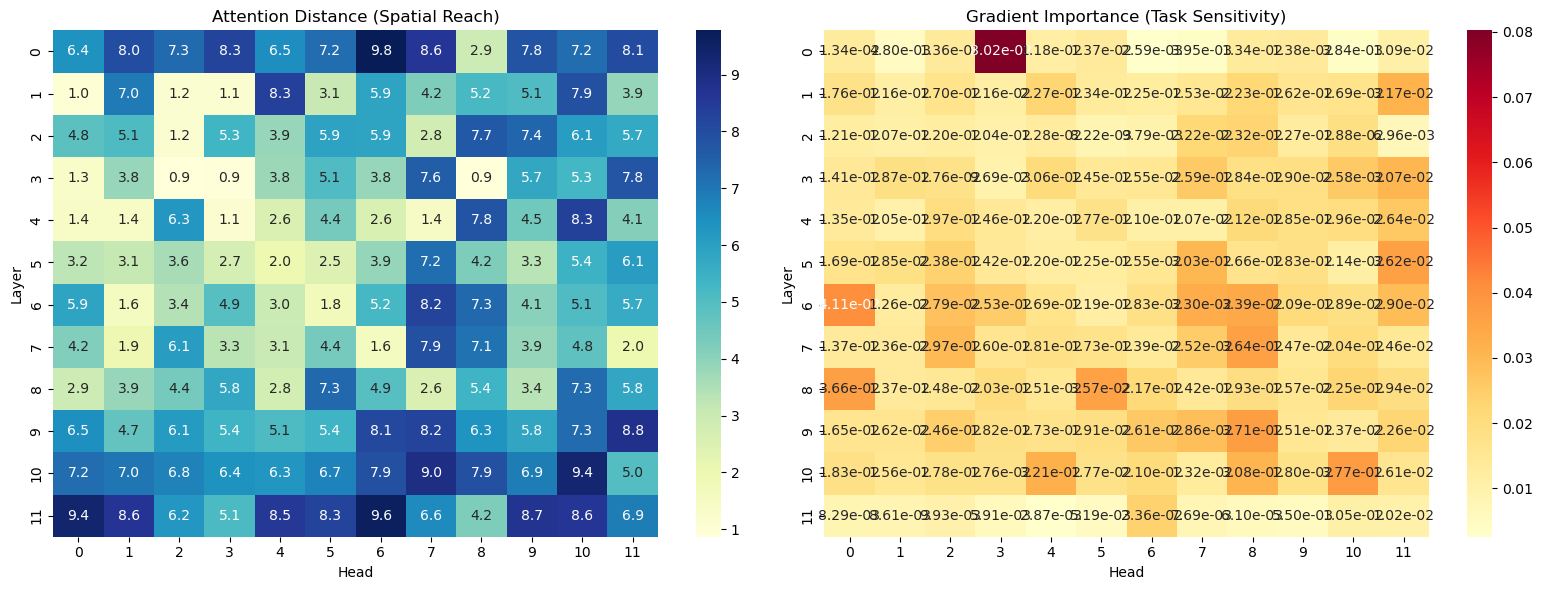

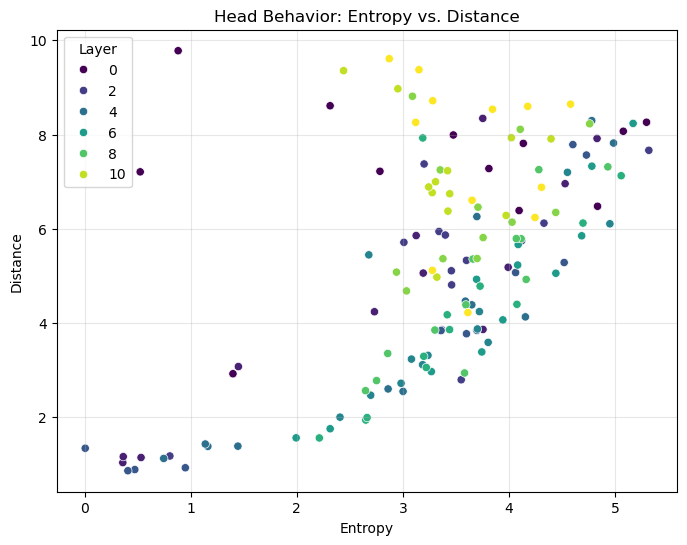

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_surgeon_heatmaps(df):
    # Set up the figure with two side-by-side plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Distance Heatmap (Is it Local or Global?)
    # We pivot the dataframe to get a Layer x Head grid
    dist_pivot = df.pivot(index="Layer", columns="Head", values="Distance")
    sns.heatmap(dist_pivot, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0])
    axes[0].set_title("Attention Distance (Spatial Reach)")
    
    # 2. Importance Heatmap (Which heads are 'vital'?)
    imp_pivot = df.pivot(index="Layer", columns="Head", values="Importance")
    sns.heatmap(imp_pivot, annot=True, fmt=".2e", cmap="YlOrRd", ax=axes[1])
    axes[1].set_title("Gradient Importance (Task Sensitivity)")
    
    plt.tight_layout()
    plt.show()

# Run it with your census data
plot_surgeon_heatmaps(df_census)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_census, x="Entropy", y="Distance", hue="Layer", palette="viridis")
plt.title("Head Behavior: Entropy vs. Distance")
plt.grid(True, alpha=0.3)
plt.show()